### **1) Gerekli Kütüphanelerin İçe Aktarılması / Importing Required Libraries**

Veri işleme (`pandas`, `numpy`) ve görselleştirme (`matplotlib`, `seaborn`) için temel kütüphaneleri içe aktarıyoruz.

*We import the core libraries for data processing (`pandas`, `numpy`) and visualization (`matplotlib`, `seaborn`).*


In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **2) Model ve Metrik Kütüphanelerinin İçe Aktarılması / Importing Model & Metric Librarie**

Hem regresyon (`LinearRegression`, `PolynomialFeatures`) hem de sınıflandırma (`LogisticRegression`) için gereken sınıfları, ayrıca her iki problem türüne uygun metrikleri (`r2_score`/`mean_squared_error` regresyon için; `accuracy_score`/`confusion_matrix`/`classification_report` sınıflandırma için) baştan içe aktarıyoruz.

*We import classes for both regression (`LinearRegression`, `PolynomialFeatures`) and classification (`LogisticRegression`), along with the appropriate metrics for each problem type (`r2_score`/`mean_squared_error` for regression; `accuracy_score`/`confusion_matrix`/`classification_report` for classification), all from the start.*


In [149]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

### **3) Veri Setinin Yüklenmesi / Loading the Dataset**

`Algerian_forest_fires_dataset.csv` dosyasını okuyoruz — hava durumu ölçümleri ve Kanada Yangın Hava Durumu İndeksi (FWI) bileşenlerinden yangın olup olmadığını (`Classes`) tahmin etmeye çalışacağımız bir veri seti.

*We load the `Algerian_forest_fires_dataset.csv` file — a dataset where we will try to predict whether a fire occurred (`Classes`) from weather measurements and Canadian Fire Weather Index (FWI) components.*


In [150]:
df = pd.read_csv("../../Data/4-Algerian_forest_fires_dataset.csv")

### **4) Veriye İlk Bakış / First Look at the Data**

`df.head()` ile veri setinin yapısını görüyoruz.

*We view the structure of the dataset with `df.head()`.*


In [151]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


### **5) Eksik Veri Kontrolü / Missing Data Check**

`df.isnull().sum()` ile her kolonda kaç eksik değer olduğuna bakıyoruz.

*We check how many missing values each column has using `df.isnull().sum()`.*


In [152]:
df.isnull().sum()

day            1
month          2
year           2
Temperature    2
 RH            2
 Ws            2
Rain           2
FFMC           2
DMC            2
DC             2
ISI            2
BUI            2
FWI            2
Classes        3
dtype: int64

### **6) Eksik Değerli Satırları İnceleme / Inspecting Rows with Missing Values**

Bu veri setine özgü bilinen bir durum: iki farklı bölgenin (Bejaia / Sidi-Bel Abbes) verileri tek CSV'de alt alta birleştirilmiş ve aralarına **bölge başlığı / tekrar eden kolon başlığı** gibi "sahte" satırlar sızmış. `df[df.isnull().any(axis=1)]` ile bu satırları görüyoruz.

*A known quirk of this dataset: two regions (Bejaia / Sidi-Bel Abbes) are stacked in a single CSV, and "fake" rows (a region title, a repeated column header) have leaked in between them. We view these rows with `df[df.isnull().any(axis=1)]`.*


In [153]:
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


### **7) Sahte/Bozuk Satırların Kaldırılması / Removing Fake / Corrupted Rows**

122 ve 123. satırlar bölge başlığı satırları; 168. satır ise `DC` kolonunda iki değerin birleştiği (`"14.6 9"`), bu yüzden tüm sonraki kolonların kaydığı bozuk bir satır. Üçünü de veri setinden çıkarıyoruz.

*Rows 122 and 123 are region-header rows; row 168 has two values merged into the `DC` column (`"14.6 9"`), which shifts all subsequent columns — a corrupted row. We remove all three from the dataset.*


In [154]:
df.drop([122, 123, 168], inplace=True)

### **8) Temizliğin Doğrulanması / Verifying the Cleanup**

*We verify the cleanup.*


In [155]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [156]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
dtype: int64

### **9) Kolon Tiplerinin Kontrolü / Checking Column Data Types**

`df.info()` çalıştırdığımızda tüm kolonların hâlâ `str` (metin) tipinde olduğunu görüyoruz — CSV'den okunurken sayısal kolonlar da metin olarak gelmiş. Bu, birazdan düzelteceğimiz önemli bir nokta.

*Running `df.info()` shows that all columns are still of type `str` (text) — even the numeric columns were read in as text. This is an important issue we will fix shortly.*


In [157]:
df.info()

<class 'pandas.DataFrame'>
Index: 244 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          244 non-null    str  
 1   month        244 non-null    str  
 2   year         244 non-null    str  
 3   Temperature  244 non-null    str  
 4    RH          244 non-null    str  
 5    Ws          244 non-null    str  
 6   Rain         244 non-null    str  
 7   FFMC         244 non-null    str  
 8   DMC          244 non-null    str  
 9   DC           244 non-null    str  
 10  ISI          244 non-null    str  
 11  BUI          244 non-null    str  
 12  FWI          244 non-null    str  
 13  Classes      244 non-null    str  
dtypes: str(14)
memory usage: 28.6 KB


### **10) Kolon İsimlerindeki Sorunları Görme / Spotting Issues in Column Names**

`df.columns` çıktısında bazı kolon isimlerinin başında/sonunda **görünmeyen boşluk karakterleri** olduğunu görüyoruz (`' RH'`, `'Rain '`, `'Classes  '` gibi) — bu, `df["Classes"]` gibi doğrudan erişimlerin `KeyError` vermesinin sebebiydi.

*The `df.columns` output shows that some column names have **invisible leading/trailing whitespace** (like `' RH'`, `'Rain '`, `'Classes  '`) — this is what caused direct access like `df["Classes"]` to raise a `KeyError`.*


In [158]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  '],
      dtype='str')

### **11) Kolon İsimlerini Temizleme / Cleaning Column Names**

`str.strip()` ile baştaki/sondaki boşlukları, `str.lower()` ile de tüm kolon isimlerini küçük harfe çevirerek tutarlı, güvenilir isimler elde ediyoruz.

*We use `str.strip()` to remove leading/trailing whitespace and `str.lower()` to make all column names lowercase, giving us consistent, reliable names.*


In [159]:
df.columns = df.columns.str.strip()

In [160]:
df.columns = df.columns.str.lower()

In [161]:
df.head()

,day,month,year,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [162]:
df.columns

Index(['day', 'month', 'year', 'temperature', 'rh', 'ws', 'rain', 'ffmc',
       'dmc', 'dc', 'isi', 'bui', 'fwi', 'classes'],
      dtype='str')

### **12) İlgisiz Kolonların Kaldırılması / Dropping Irrelevant Columns**

`day`, `month`, `year` kolonları, yangın riskini belirleyen fiziksel/meteorolojik bir bilgi taşımıyor (tarih bilgisi, hava durumu değişkenleri üzerinden zaten dolaylı yoluyla temsil ediliyor) — bu yüzden özellik setinden çıkarıyoruz.

⚠️ **Düzeltme / Fix:** Orijinal kodda `df.drop(df[["day","month","year"]], axis=1, inplace=True)` yazılmıştı — bu, `drop()`'a kolon **isimleri** yerine bir **DataFrame** veriyor. Bu "tesadüfen" çalışır çünkü bir DataFrame'in üzerinde döngü kurulduğunda (`for x in df`) pandas onun kolon isimlerini döndürür — ama bu güvenilir/standart bir kullanım değil. Doğrusu, `columns=` parametresiyle doğrudan isim listesi vermek:

*In the original code, `df.drop(df[["day","month","year"]], axis=1, inplace=True)` passed a **DataFrame** to `drop()` instead of column **names**. This "worked" only by accident, because iterating over a DataFrame (`for x in df`) yields its column names — but this is not a reliable or standard usage. The correct way is to pass the name list directly via the `columns=` parameter (see code below).*


In [ ]:
df.drop(columns=["day", "month", "year"], inplace=True)

In [115]:
df.head()

,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,classes
0,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


### **13) `classes` Kolonundaki Benzersiz Değerleri İnceleme / Inspecting Unique Values in `classes`**

`.unique()` ile hedef değişkenimizin gerçekte kaç farklı (ve ne kadar "kirli") değer aldığına bakıyoruz.

*We use `.unique()` to see how many distinct (and how "dirty") values our target variable actually contains.*


In [116]:
df["classes"].unique()

<StringArray>
[  'not fire   ',       'fire   ',          'fire',         'fire ',
      'not fire',     'not fire ',     'Classes  ', 'not fire     ',
  'not fire    ']
Length: 9, dtype: str

### **14) Kalan Bir "Sahte Başlık" Satırının Tespiti ve Kaldırılması / Detecting and Removing One More "Fake Header" Row**

`unique()` çıktısında `'Classes  '` diye bir değer görüyoruz — bu, veri setinin ortasına sızmış **başka bir kolon başlığı satırı** (122/123'e benzer, ama farklı bir konumda) ve `temperature`, `rh` gibi kolonlarda da hâlâ metin değerleri (`"Temperature"`, `"RH"` ...) taşıyor. Bu satırı bulup kaldırıyoruz.

*The `unique()` output shows a value `'Classes  '` — this is **another column-header row** that has leaked into the middle of the dataset (similar to rows 122/123), and it still carries text values (`"Temperature"`, `"RH"`, ...) in columns like `temperature`, `rh`. We locate and remove it.*


In [117]:
df[df["classes"] == "Classes  "]

,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,classes
124,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes


In [118]:
df.drop([124], inplace=True)

In [119]:
df[df["classes"] == "Classes  "]  # boş dönmeli / should return empty

,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,classes


### **15) `classes` Değerlerini Temizleme / Cleaning the `classes` Values**

Kolon isimlerinde olduğu gibi, `classes` kolonunun **içindeki metin değerlerinde** de baştaki/sondaki boşluklar var (`'fire   '`, `'not fire '` gibi farklı varyasyonlar). `str.strip()` ile bunları temizleyip tek tip hale getiriyoruz.

*Just like the column names, the **text values** inside the `classes` column also had leading/trailing whitespace (variations like `'fire   '`, `'not fire '`). We clean these with `str.strip()` to make them consistent.*


In [120]:
df["classes"] = df["classes"].str.strip()

In [121]:
df["classes"].unique()

<StringArray>
['not fire', 'fire']
Length: 2, dtype: str

### **16) 🔧 Sayısal Kolonların Gerçek Sayı Tipine Çevrilmesi / Converting Numeric Columns to Actual Numeric Types (Fix)**

⚠️ **Eksik olan adım / Missing step:** Kolon isimlerini temizledik, ama kolonların **içindeki değerler** hâlâ `str` tipindeydi (9. adımdaki `df.info()` çıktısını hatırla). Bu adımı, tüm "sahte header" satırları (122, 123, 168, 124) kaldırıldıktan **sonra** çalıştırıyoruz — aksi halde `pd.to_numeric()`, satır 124'teki `"Temperature"` gibi gerçek metin değerlerini sayıya çeviremeyip hata verir. Şimdiye kadar model kısmında (`StandardScaler`, `PolynomialFeatures`) her şeyin çalışması, `scikit-learn`'ün metin halindeki sayıları (`"29"` gibi) arka planda otomatik sayıya çevirmesi sayesindeydi — ama bu güvenilmez bir alışkanlıktır. Şimdi tüm sayısal kolonları açıkça `pd.to_numeric()` ile gerçek sayı tipine çeviriyoruz.

*We cleaned the column **names**, but the **values** inside them were still of type `str` (recall the `df.info()` output from step 9). We run this step **after** all "fake header" rows (122, 123, 168, 124) have been removed — otherwise `pd.to_numeric()` would fail trying to convert genuine text like `"Temperature"` in row 124. Up to now, things "worked" in the modeling section only because `scikit-learn` silently converts numeric-looking strings (like `"29"`) to numbers behind the scenes — but this is an unreliable habit. We now explicitly convert all numeric columns to proper numeric types using `pd.to_numeric()`.*


In [122]:
numeric_cols = ["temperature", "rh", "ws", "rain", "ffmc", "dmc", "dc", "isi", "bui", "fwi"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)
df.info()

<class 'pandas.DataFrame'>
Index: 243 entries, 0 to 246
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  243 non-null    int64  
 1   rh           243 non-null    int64  
 2   ws           243 non-null    int64  
 3   rain         243 non-null    float64
 4   ffmc         243 non-null    float64
 5   dmc          243 non-null    float64
 6   dc           243 non-null    float64
 7   isi          243 non-null    float64
 8   bui          243 non-null    float64
 9   fwi          243 non-null    float64
 10  classes      243 non-null    str    
dtypes: float64(7), int64(3), str(1)
memory usage: 22.8 KB


### **17) Hedef Değişkenin Sayısallaştırılması / Encoding the Target Variable**

`classes` artık temiz bir şekilde sadece `"fire"`/`"not fire"` değerlerini alıyor. `.map()` ile bunu `1`/`0`'a çeviren yeni bir `new_classes` kolonu oluşturuyoruz — bu bizim **sınıflandırma hedefimiz** olacak.

*`classes` now cleanly contains only `"fire"`/`"not fire"`. We use `.map()` to create a new `new_classes` column encoding this as `1`/`0` — this will be our **classification target**.*


In [123]:
df["new_classes"] = df["classes"].map({"not fire": 0, "fire": 1})

In [124]:
df.head()

,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,classes,new_classes
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [125]:
df.drop("classes", axis=1, inplace=True)

In [126]:
df.head()

,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,new_classes
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0


### **18) Korelasyon Isı Haritası / Correlation Heatmap**

Artık tüm kolonlar sayısal olduğu için `df.corr()` güvenilir bir şekilde çalışır. Bu, hangi özelliklerin hedefle (`new_classes`) ve birbiriyle (multicollinearity) ne kadar ilişkili olduğunu gösteriyor.

*Now that all columns are numeric, `df.corr()` works reliably. This shows how strongly each feature relates to the target (`new_classes`) and to each other (multicollinearity).*


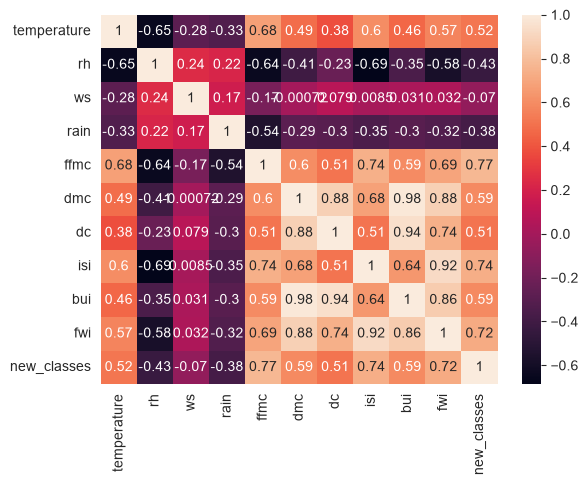

In [127]:
sns.heatmap(df.corr(), annot=True)
plt.show()

### **19) Özellik (X) ve Hedef (y) Ayrımı / Separating Features (X) and Target (y)**

`X`, tüm hava durumu ve FWI-sistemi ölçümlerini içeriyor; `y` ise sayısallaştırdığımız `new_classes` (0 = yangın yok, 1 = yangın var).

*`X` contains all weather and FWI-system measurements; `y` is our encoded `new_classes` (0 = no fire, 1 = fire).*


In [128]:
X = df[["temperature", "rh", "ws", "rain", "ffmc", "dmc", "dc", "isi", "bui", "fwi"]]
y = df["new_classes"]

### **20) Eğitim/Test Ayrımı / Train/Test Split**

Veriyi `train_test_split` ile **%75 eğitim / %25 test** olarak ayırıyoruz.

*We split the data into **75% training / 25% test** using `train_test_split`.*


In [129]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

### **21) Özellik Ölçeklendirme / Feature Scaling**

$$
z = \frac{x - \mu}{\sigma}
$$

👍 **Doğru adım:** `scaler.fit_transform(X_train)` ile ölçek sadece eğitim verisinden öğreniliyor, `scaler.transform(X_test)` ile test verisine yeniden öğrenilmeden uygulanıyor.

*👍 **Correct step:** `scaler.fit_transform(X_train)` learns the scale only from the training data, and `scaler.transform(X_test)` applies it to the test data without re-learning.*


In [130]:
scaler = StandardScaler()

In [131]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [132]:
X_train

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.62963326,
        -0.77269802, -0.81640219],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.93058524,
        -0.90344718, -0.89470108],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  2.7271388 ,
         0.38339978,  1.8849096 ],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.06948615,
        -1.03419633, -0.92080071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.5973248 ,
         0.18383528,  0.48857935],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.86113478,
        -0.99290713, -0.89470108]], shape=(182, 10))

### **22) 🚨 Linear Regression'ı Deneme — ve Neden Bu Problem İçin Yanlış Araç Olduğunu Görme / Trying Linear Regression — and Seeing Why It's the Wrong Tool Here**

`new_classes` sürekli bir sayı değil, **ikili (binary) bir kategori** (0 = not fire, 1 = fire) — yani bu aslında bir **sınıflandırma (classification)** problemi, regresyon değil. Yine de, neden işe yaramadığını somut olarak görmek için Linear Regression'ı bilerek burada deniyoruz.

*`new_classes` is not a continuous number — it's a **binary category** (0 = not fire, 1 = fire), meaning this is actually a **classification** problem, not regression. Still, we deliberately try Linear Regression here so we can concretely see why it doesn't work.*


In [133]:
regression = LinearRegression()

In [134]:
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[-0.01, 0.15,-0.03,..., 0.14, 0.3 , 0.18]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.5495
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[32.48,17.07,13.15,..., 4.2 , 1.81, 0.41]"


In [135]:
y_pred = regression.predict(X_test)

In [136]:
r2_score(y_test, y_pred)

0.6646824298727511

⚠️ **Yorum / Interpretation:** `R²` skoru burada kavramsal olarak **anlamsız** — Linear Regression, 0 ve 1 dışında da sürekli değerler (örn. -0.2, 1.4 gibi) üretir ve bunları "sınıf" olarak yorumlamanın geçerli bir yolu yoktur. Bu adım, doğru araç seçiminin neden önemli olduğunu göstermek için burada bilerek bırakıldı — sıradaki bölümde bunu doğru şekilde (Logistic Regression ile) çözeceğiz.

*The `R²` score here is conceptually **meaningless** — Linear Regression produces continuous values outside 0 and 1 (e.g., -0.2, 1.4) with no valid way to interpret them as a "class". This step is deliberately kept here to demonstrate why choosing the right tool matters — we will solve this correctly (with Logistic Regression) in the next section.*


### **23) Polinom Özellik Dönüşümü / Polynomial Feature Transformation**

⚠️ **Düzeltme / Fix:** Orijinal kodda `X_test_poly = poly.fit_transform(X_test)` yazılmıştı — test setinde de `fit_transform()` çağrılmıştı. Doğrusu, sadece `X_train`'de `fit_transform()`, `X_test`'te ise `transform()` kullanmak — tıpkı `StandardScaler` adımında yaptığımız gibi.

*In the original code, `X_test_poly = poly.fit_transform(X_test)` called `fit_transform()` on the test set as well. The correct approach is to use `fit_transform()` only on `X_train` and `transform()` on `X_test` — exactly as we did in the `StandardScaler` step.*


In [137]:
poly = PolynomialFeatures(degree=2)

In [138]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)   # fit değil, sadece transform

### **24) 🚨 Polynomial Regression'ı Deneme — Aynı Kavramsal Sorun / Trying Polynomial Regression — Same Conceptual Problem**

Polinom terimleri eklemek, **problem türünü değiştirmez** — hâlâ ikili bir kategoriyi sürekli bir regresyon modeliyle tahmin etmeye çalışıyoruz. Beklenildiği gibi, sonuç yine anlamlı bir `R²` üretmeyecek.

*Adding polynomial terms does **not change the problem type** — we are still trying to predict a binary category with a continuous regression model. As expected, the result will again fail to produce a meaningful `R²`.*


In [139]:
regression.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](66,)","[ 0. ,-0.1 , 0.12,...,-4.33, 9.01, 1.78]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.808
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,66
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(65)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](66,)","[84.86,80.2 ,51.16,..., 0.02, 0.01, 0. ]"


In [140]:
y_pred_poly = regression.predict(X_test_poly)

In [141]:
r2_score(y_test, y_pred_poly)

-1.28795806992676

## ✅ Logistic Regression (Doğru Yaklaşım / The Correct Approach)

### **25) Neden Logistic Regression / Why Logistic Regression**

`new_classes` ikili bir kategori olduğu için, doğru araç **Logistic Regression**'dır — bu model, çıktıyı `0` ile `1` arasında bir **olasılık** olarak üretir (sigmoid fonksiyonu ile) ve bir eşik değerine (varsayılan `0.5`) göre sınıfa (`fire`/`not fire`) çevirir. Değerlendirme için de artık `R²` değil, **sınıflandırma metrikleri** (`accuracy`, `confusion matrix`, `precision`/`recall`/`F1`) kullanıyoruz.

*Since `new_classes` is a binary category, the correct tool is **Logistic Regression** — this model produces output as a **probability** between `0` and `1` (via the sigmoid function) and converts it to a class (`fire`/`not fire`) using a threshold (default `0.5`). For evaluation, we now use **classification metrics** (`accuracy`, `confusion matrix`, `precision`/`recall`/`F1`) instead of `R²`.*


In [142]:
log_model = LogisticRegression()

In [143]:
log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [144]:
y_pred_log = log_model.predict(X_test)

### **26) Sınıflandırma Performansının Değerlendirilmesi / Evaluating Classification Performance**

- `accuracy_score` → doğru sınıflandırılan örneklerin oranı
- `confusion_matrix` → hangi sınıfın ne kadar doğru/yanlış tahmin edildiğinin dökümü (gerçek pozitif/negatif, yanlış pozitif/negatif)
- `classification_report` → her sınıf için precision, recall, F1-score

*- `accuracy_score` → the proportion of correctly classified samples*
*- `confusion_matrix` → a breakdown of how correctly/incorrectly each class was predicted (true/false positives/negatives)*
*- `classification_report` → precision, recall, and F1-score for each class*


In [145]:
accuracy_score(y_test, y_pred_log)

0.9508196721311475

In [146]:
confusion_matrix(y_test, y_pred_log)

array([[23,  1],
       [ 2, 35]])

In [147]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94        24
           1       0.97      0.95      0.96        37

    accuracy                           0.95        61
   macro avg       0.95      0.95      0.95        61
weighted avg       0.95      0.95      0.95        61



### **27) Genel Sonuç / Overall Conclusion**

🎯 Bu notebook'un en önemli çıkarımı: **doğru model, önce doğru problem tanımından geçer.** `new_classes` ikili bir kategori olduğu için Linear/Polynomial Regression (22-24. adımlar) kavramsal olarak yanlış araçlardı ve anlamsız `R²` skorları üretti — bu bilerek gösterildi. Logistic Regression ile aynı veriye doğru açıdan yaklaştığımızda, standart sınıflandırma metrikleriyle yorumlanabilir, güvenilir bir sonuç elde ediyoruz.

*🎯 The key takeaway of this notebook: **the right model starts with the right problem definition.** Since `new_classes` is a binary category, Linear/Polynomial Regression (steps 22-24) were conceptually the wrong tools and produced meaningless `R²` scores — this was shown deliberately. Approaching the same data correctly with Logistic Regression gives us an interpretable, reliable result using standard classification metrics.*
